In [121]:
from AMOC_Detector import Detector, gaussian_mean_change, rbf_kernel
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import cauchy

***Some changes we will work with***

In [124]:
def mean_change(ts, changepoint: int, delta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    ts_new[changepoint:] += delta
    return ts_new

def variance_change(ts, changepoint: int, delta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    ts_new[changepoint:] *= delta
    return ts_new


def shape_change(ts, changepoint: int, delta: float, beta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    ts_new[changepoint:] = ts_new[changepoint:] * delta + beta
    return ts_new


def cauchy_change(ts, changepoint: int, delta: float, beta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    tail_shape = ts_new[changepoint:].shape
    ts_new[changepoint:] = ts_new[changepoint:] + cauchy.rvs(loc=delta, scale=beta, size=tail_shape)
    return ts_new



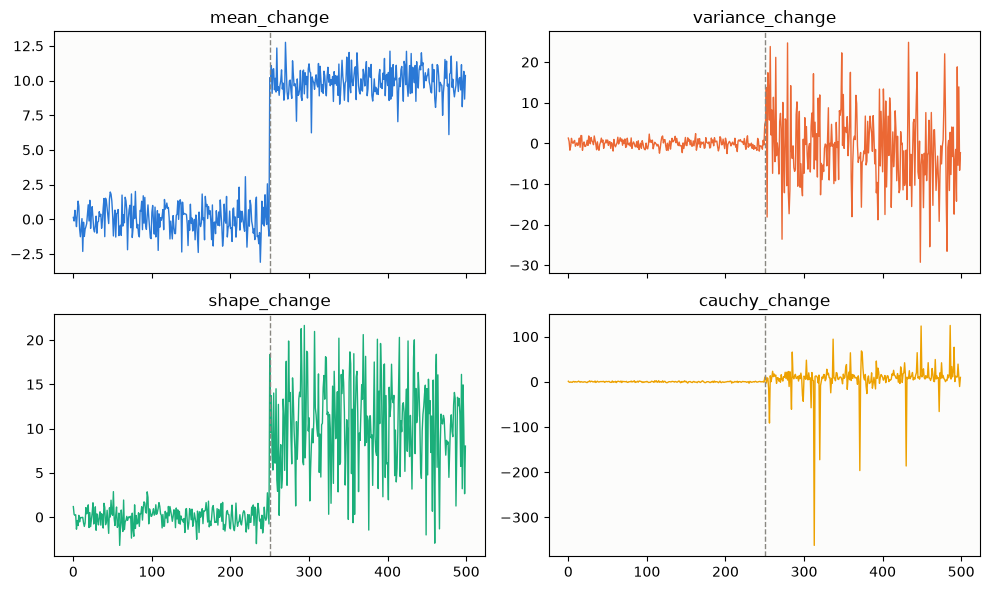

In [ ]:

colors = {
    "mean_change": "#2a78d6",      # blue
    "variance_change": "#eb6834",  # orange
    "shape_change": "#1baf7a",     # aqua
    "cauchy_change": "#eda100",    # yellow
}

fns = {
    "mean_change": lambda ts, cp: mean_change(ts, cp, delta=10),
    "variance_change": lambda ts, cp: variance_change(ts, cp, delta=10),
    "shape_change": lambda ts, cp: shape_change(ts, cp, delta=5, beta=10),
    "cauchy_change": lambda ts, cp: cauchy_change(ts, cp, delta=10, beta=5),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
rng = np.random.default_rng(0)

for ax, (name, fn) in zip(axes.flat, fns.items()):
    ts = rng.multivariate_normal(mean=np.zeros(1), cov=np.eye(1), size=500)
    changepoint = 250
    ts_shifted = fn(ts, changepoint)

    ax.plot(ts_shifted[:, 0], color=colors[name], linewidth=1)
    ax.axvline(changepoint, color="#898781", linestyle="--", linewidth=1)  # muted ink
    ax.set_title(name)
    ax.set_facecolor("#fcfcfb")

fig.tight_layout()
plt.show()


This is a very basic function for beta tuning our values using using MC methods to find the 0.05 percentile

In [89]:
def beta_tuning(alpha,cost_function,dim) -> float:
    maxima = []
    for i in range(500):
        ts = np.random.multivariate_normal(mean=np.zeros(dim),cov = np.eye(dim),size = 500)
        maxima.append(np.max(cost_function(ts)))
    return float(np.quantile(maxima,1-alpha)) 

print(beta_tuning(0.05,rbf_kernel,5))

1.2272631938482546


In [ ]:
def statistical_test_v1(change_type_fn, delta, alpha, tests, dim, beta=1) -> dict:
    gaussian_beta = beta_tuning(alpha, gaussian_mean_change, dim)
    rbf_beta = beta_tuning(alpha, rbf_kernel, dim)
    parametric_detector = Detector(cost_function=gaussian_mean_change, penalty=gaussian_beta)
    kernel_detector = Detector(cost_function=rbf_kernel, penalty=rbf_beta)
    counts = {"RBF": 0, "Gaussian": 0}

    for i in range(tests):
        ts = np.random.multivariate_normal(mean=np.zeros(dim), cov=np.eye(dim), size=500)
        changepoint = int(np.ceil(np.random.uniform(25, 475)))
        ts_shifted = change_type_fn(ts, changepoint, delta, beta=beta)

        result = parametric_detector.detect(time_series=ts_shifted)
        if result is not None and result[0][0] == changepoint:
            counts["Gaussian"] += 1

        result = kernel_detector.detect(time_series=ts_shifted)
        if result is not None and result[0][0] == changepoint:
            counts["RBF"] += 1
    counts = {k: v / tests for k, v in counts.items()}
    return counts


Here I will create a power function for my code

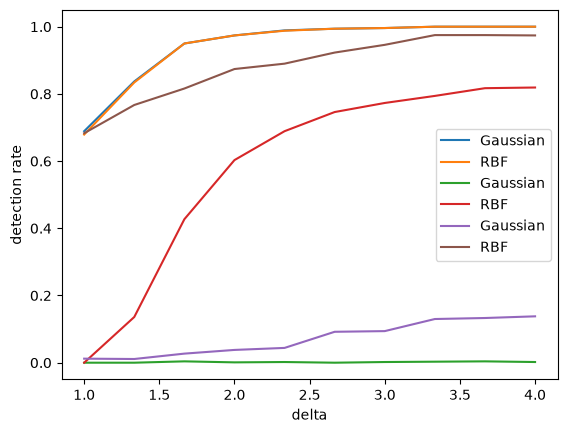

In [138]:
def power(change_type_fn, alpha, tests, dim, beta=1):
    x = np.linspace(1, 4, 10)   # 10 delta values from 1 to 20
    results = {"RBF": [], "Gaussian": []}
    for i in x:
        result = statistical_test_v1(change_type_fn=change_type_fn, delta=i, alpha=alpha, tests=tests, dim=dim, beta=1)
        results["RBF"].append(result["RBF"])
        results["Gaussian"].append(result["Gaussian"])

    plt.plot(x, results["Gaussian"], label="Gaussian")
    plt.plot(x, results["RBF"], label="RBF")
    plt.xlabel("delta")
    plt.ylabel("detection rate")
    plt.legend()
power(change_type_fn=mean_change, alpha=0.05, tests=1000, dim=5)
power(change_type_fn=variance_change, alpha=0.05, tests=1000, dim=5)
power(change_type_fn=cauchy_change, alpha=0.05, tests=1000, dim=5)



**Possible ways I could build it further**
1) Implement Neyman-Pearson liklihood ratio as a theoretical upper bound
2) How differering size has on the effect of detection
3) add real life application